In [1]:
# --- Cell 1: Imports ---
from openeye import oechem, oeomega, oeshape, oezap
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import matplotlib.pyplot as plt
import time

# Load OpenEye license
oechem.OEAddLicenseData(open(r"C:\Users\Admin\.OpenEye\oe_license.txt").read())

In [2]:
# --- Cell 2: Load and Clean Data ---
# Load the CSV
df = pd.read_csv("antiviral_potency_2025_unblinded.csv")
print(f"Total molecules in dataset: {len(df)}")
print(f"Columns: {list(df.columns)}")

# Define target columns
SARS_COL = "pIC50 (SARS-CoV-2 Mpro)"
MERS_COL = "pIC50 (MERS-CoV Mpro)"

# Check missing values
print(f"\nMissing values:")
print(f"  SARS-CoV-2 pIC50: {df[SARS_COL].isna().sum()}")
print(f"  MERS-CoV pIC50:   {df[MERS_COL].isna().sum()}")

# Strategy: use only molecules that have BOTH pIC50 values
# This way SARS and MERS models share the same ROCS matrix
working_df = df[["CXSMILES", "Molecule Name", "Set", SARS_COL, MERS_COL]].dropna()
print(f"\nMolecules with both SARS and MERS pIC50: {len(working_df)}")
print(f"  Train: {(working_df['Set'] == 'Train').sum()}")
print(f"  Test:  {(working_df['Set'] == 'Test').sum()}")

# Quick look at target distributions
print(f"\nSARS pIC50 stats:")
print(working_df[SARS_COL].describe())
print(f"\nMERS pIC50 stats:")
print(working_df[MERS_COL].describe())

Total molecules in dataset: 1328
Columns: ['CXSMILES', 'Molecule Name', 'Set', 'pIC50 (MERS-CoV Mpro)', 'pIC50 (SARS-CoV-2 Mpro)']

Missing values:
  SARS-CoV-2 pIC50: 223
  MERS-CoV pIC50:   130

Molecules with both SARS and MERS pIC50: 975
  Train: 712
  Test:  263

SARS pIC50 stats:
count    975.000000
mean       5.671169
std        1.168357
min        4.000000
25%        4.720000
50%        5.380000
75%        6.560000
max        8.730000
Name: pIC50 (SARS-CoV-2 Mpro), dtype: float64

MERS pIC50 stats:
count    975.000000
mean       4.962697
std        0.862631
min        1.000000
25%        4.310000
50%        4.780000
75%        5.510000
max        9.000000
Name: pIC50 (MERS-CoV Mpro), dtype: float64


In [3]:
# --- Cell 3: Generate 3D Conformers with OMEGA ---
print("\n--- Generating 3D Conformers ---")

omega_opts = oeomega.OEOmegaOptions(oeomega.OEOmegaSampling_ROCS)
omega = oeomega.OEOmega(omega_opts)

mol_list = []
sars_values = []
mers_values = []
set_labels = []
mol_names = []
failed_count = 0

for idx, row in working_df.iterrows():
    smiles = row["CXSMILES"]
    mol = oechem.OEMol()
    oechem.OESmilesToMol(mol, smiles)

    ret_code = omega.Build(mol)
    if ret_code == oeomega.OEOmegaReturnCode_Success:
        mol_list.append(oechem.OEMol(mol))
        sars_values.append(row[SARS_COL])
        mers_values.append(row[MERS_COL])
        set_labels.append(row["Set"])
        mol_names.append(row["Molecule Name"])
    else:
        failed_count += 1

N = len(mol_list)
print(f"Successfully generated 3D conformers: {N}")
print(f"Failed: {failed_count}")

# Convert to numpy arrays
sars_values = np.array(sars_values)
mers_values = np.array(mers_values)
set_labels = np.array(set_labels)


--- Generating 3D Conformers ---
Successfully generated 3D conformers: 963
Failed: 12


In [4]:
# --- Cell 5: Load Saved Matrices ---
# (If you restart the kernel, run Cell 1 first for imports, then this cell)
shape_matrix = np.load("shape_matrix_both.npy")
color_matrix = np.load("color_matrix_both.npy")
sars_values = np.load("sars_values.npy")
mers_values = np.load("mers_values.npy")
set_labels = np.load("set_labels.npy", allow_pickle=True)
N = len(sars_values)
print(f"Loaded data for {N} molecules")

Loaded data for 963 molecules


In [5]:
# --- Cell 6: Build Feature Matrix (Lightweight Only) ---
# Calculate lightweight features from 3D conformers
print("Calculating lightweight features...")
lightweight_features = []
area_calc = oezap.OEArea()

for mol in mol_list:
    num_atoms = mol.NumAtoms()
    num_bonds = mol.NumBonds()
    volume = oeshape.OECalcVolume(mol)
    surface_area = area_calc.GetArea(mol)

    pmi = oechem.OEDoubleArray(3)
    oechem.OECalcPMI(pmi, mol)
    pmi_vals = [pmi[0], pmi[1], pmi[2]]
    max_pmi = max(pmi_vals) if max(pmi_vals) > 0 else 1.0
    npr1 = pmi_vals[0] / max_pmi
    npr2 = pmi_vals[1] / max_pmi

    lightweight_features.append([num_atoms, num_bonds, volume, surface_area, npr1, npr2])

features = np.array(lightweight_features)
print(f"Feature matrix shape: {features.shape}")
print(f"  Features: [num_atoms, num_bonds, volume, surface_area, npr1, npr2]")

# Train/Test split
train_mask = set_labels == "Train"
test_mask = set_labels == "Test"

train_X = features[train_mask]
test_X = features[test_mask]

train_y_sars = sars_values[train_mask]
test_y_sars = sars_values[test_mask]

train_y_mers = mers_values[train_mask]
test_y_mers = mers_values[test_mask]

print(f"\nTrain set: {train_X.shape[0]} molecules, {train_X.shape[1]} features")
print(f"Test set:  {test_X.shape[0]} molecules, {test_X.shape[1]} features")

Calculating lightweight features...
Feature matrix shape: (963, 6)
  Features: [num_atoms, num_bonds, volume, surface_area, npr1, npr2]

Train set: 701 molecules, 6 features
Test set:  262 molecules, 6 features


In [6]:
# --- Cell 7: Define Evaluation Function ---
def evaluate_model(name, y_true, y_pred):
    """Print evaluation metrics for a model."""
    rho, _ = spearmanr(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Spearman rho:  {rho:.4f}")
    print(f"  MAE:           {mae:.4f}")
    print(f"  RMSE:          {rmse:.4f}")
    print(f"{'='*50}")
    return rho, mae, rmse

def plot_predicted_vs_actual(y_true, y_pred, title):
    """Scatter plot of predicted vs actual values."""
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(y_true, y_pred, s=15, alpha=0.6)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.3, label="Perfect prediction")
    ax.set_xlabel("Experimental pIC50")
    ax.set_ylabel("Predicted pIC50")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

  MODEL A: Predicting SARS-CoV-2 Mpro pIC50

  SARS - Random Forest
  Spearman rho:  0.7503
  MAE:           0.8509
  RMSE:          1.0316


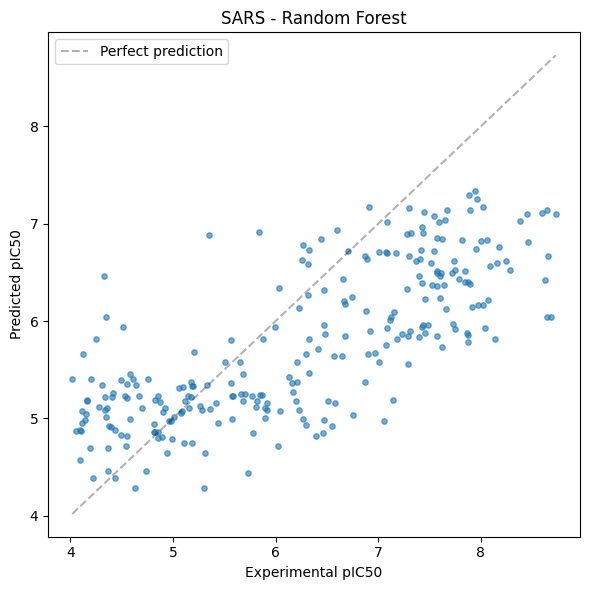


  SARS - XGBoost
  Spearman rho:  0.6982
  MAE:           0.8556
  RMSE:          1.0655


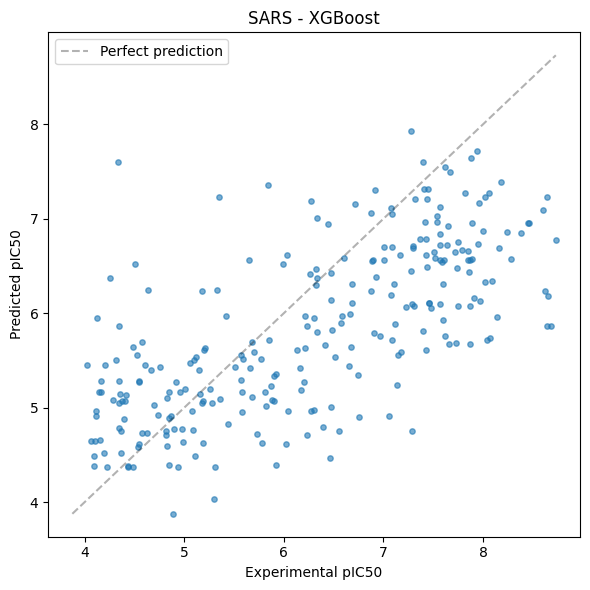

In [7]:
# --- Cell 8: Model A - Predict SARS-CoV-2 pIC50 ---
print("=" * 60)
print("  MODEL A: Predicting SARS-CoV-2 Mpro pIC50")
print("=" * 60)

# Random Forest
rf_sars = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_sars.fit(train_X, train_y_sars)
rf_sars_pred = rf_sars.predict(test_X)
rf_sars_metrics = evaluate_model("SARS - Random Forest", test_y_sars, rf_sars_pred)
plot_predicted_vs_actual(test_y_sars, rf_sars_pred, "SARS - Random Forest")

# XGBoost
xgb_sars = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_sars.fit(train_X, train_y_sars)
xgb_sars_pred = xgb_sars.predict(test_X)
xgb_sars_metrics = evaluate_model("SARS - XGBoost", test_y_sars, xgb_sars_pred)
plot_predicted_vs_actual(test_y_sars, xgb_sars_pred, "SARS - XGBoost")

  MODEL B: Predicting MERS-CoV Mpro pIC50

  MERS - Random Forest
  Spearman rho:  0.6426
  MAE:           0.6732
  RMSE:          0.8335


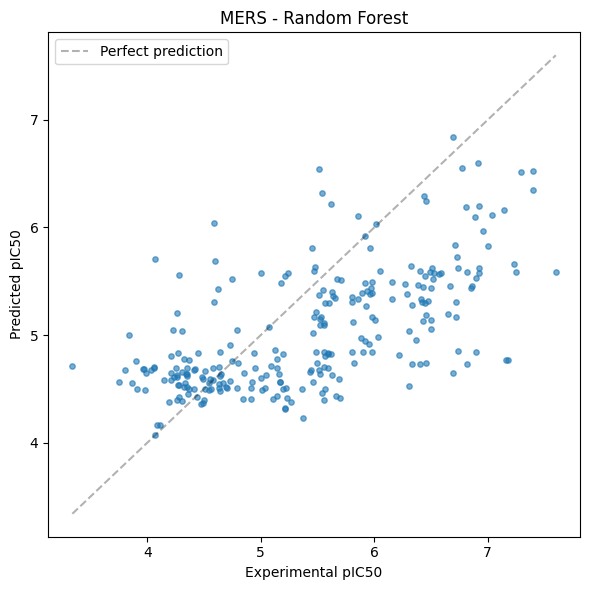


  MERS - XGBoost
  Spearman rho:  0.5724
  MAE:           0.6805
  RMSE:          0.8593


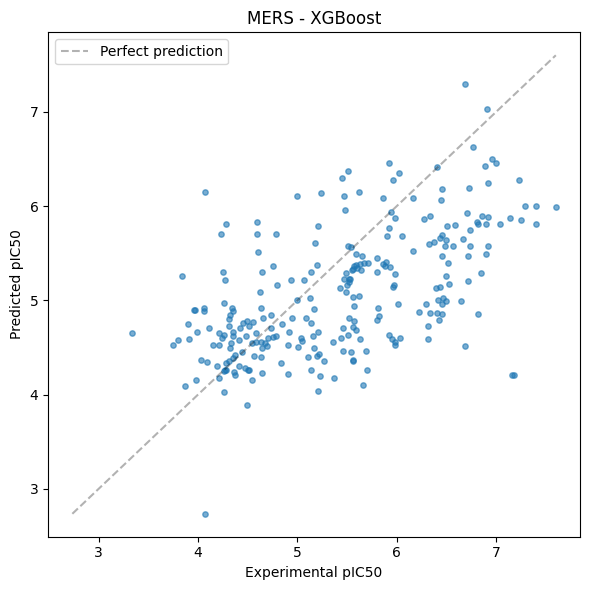

In [8]:
# --- Cell 9: Model B - Predict MERS-CoV pIC50 ---
print("=" * 60)
print("  MODEL B: Predicting MERS-CoV Mpro pIC50")
print("=" * 60)

# Random Forest
rf_mers = RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42, n_jobs=-1)
rf_mers.fit(train_X, train_y_mers)
rf_mers_pred = rf_mers.predict(test_X)
rf_mers_metrics = evaluate_model("MERS - Random Forest", test_y_mers, rf_mers_pred)
plot_predicted_vs_actual(test_y_mers, rf_mers_pred, "MERS - Random Forest")

# XGBoost
xgb_mers = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_mers.fit(train_X, train_y_mers)
xgb_mers_pred = xgb_mers.predict(test_X)
xgb_mers_metrics = evaluate_model("MERS - XGBoost", test_y_mers, xgb_mers_pred)
plot_predicted_vs_actual(test_y_mers, xgb_mers_pred, "MERS - XGBoost")

results = {
    "SARS - RF": rf_sars,
    "SARS - XGBoost": xgb_sars,
    "MERS - RF": rf_mers,
    "MERS - XGBoost": xgb_mers,
}

In [9]:
# --- Cell 10: Summary Comparison ---
print("\n" + "=" * 70)
print("  SUMMARY: All Models Comparison")
print("=" * 70)
print(f"{'Model':<25} {'Spearman':>10} {'MAE':>10} {'RMSE':>10}")
print("-" * 55)
print(f"{'SARS - Random Forest':<25} {rf_sars_metrics[0]:>10.4f} {rf_sars_metrics[1]:>10.4f} {rf_sars_metrics[2]:>10.4f}")
print(f"{'SARS - XGBoost':<25} {xgb_sars_metrics[0]:>10.4f} {xgb_sars_metrics[1]:>10.4f} {xgb_sars_metrics[2]:>10.4f}")
print(f"{'MERS - Random Forest':<25} {rf_mers_metrics[0]:>10.4f} {rf_mers_metrics[1]:>10.4f} {rf_mers_metrics[2]:>10.4f}")
print(f"{'MERS - XGBoost':<25} {xgb_mers_metrics[0]:>10.4f} {xgb_mers_metrics[1]:>10.4f} {xgb_mers_metrics[2]:>10.4f}")
print("=" * 70)


  SUMMARY: All Models Comparison
Model                       Spearman        MAE       RMSE
-------------------------------------------------------
SARS - Random Forest          0.7503     0.8509     1.0316
SARS - XGBoost                0.6982     0.8556     1.0655
MERS - Random Forest          0.6426     0.6732     0.8335
MERS - XGBoost                0.5724     0.6805     0.8593


In [10]:
# --- Cell 11: Overfitting Check ---
print("OVERFITTING CHECK: Train vs Test")
print("=" * 65)
print(f"{'Model':<25} {'Train Spearman':>15} {'Test Spearman':>15} {'Gap':>10}")
print("-" * 65)

for name, model, train_y, test_y, test_pred in [
    ("SARS - RF", rf_sars, train_y_sars, test_y_sars, rf_sars_pred),
    ("SARS - XGBoost", xgb_sars, train_y_sars, test_y_sars, xgb_sars_pred),
    ("MERS - RF", rf_mers, train_y_mers, test_y_mers, rf_mers_pred),
    ("MERS - XGBoost", xgb_mers, train_y_mers, test_y_mers, xgb_mers_pred),
]:
    train_pred = model.predict(train_X)
    train_rho, _ = spearmanr(train_y, train_pred)
    test_rho, _ = spearmanr(test_y, test_pred)
    gap = train_rho - test_rho
    print(f"{name:<25} {train_rho:>15.4f} {test_rho:>15.4f} {gap:>10.4f}")

print("=" * 65)
print("Gap < 0.10 = good | Gap 0.10-0.15 = okay | Gap > 0.15 = overfitting")

OVERFITTING CHECK: Train vs Test
Model                      Train Spearman   Test Spearman        Gap
-----------------------------------------------------------------
SARS - RF                          0.8881          0.7503     0.1377
SARS - XGBoost                     0.9666          0.6982     0.2684
MERS - RF                          0.8458          0.6426     0.2032
MERS - XGBoost                     0.9527          0.5724     0.3802
Gap < 0.10 = good | Gap 0.10-0.15 = okay | Gap > 0.15 = overfitting


In [11]:
# --- Cell 12: GridSearchCV for Hyperparameter Tuning ---
from sklearn.model_selection import GridSearchCV

# Parameter grids
rf_params = {
    "n_estimators": [200, 300, 500],
    "max_depth": [8, 10, 12, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
}

xgb_params = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.7, 0.8],
    "colsample_bytree": [0.7, 0.8],
}

results = {}

# --- SARS Random Forest ---
print("Tuning SARS - Random Forest...")
gs_rf_sars = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gs_rf_sars.fit(train_X, train_y_sars)
print(f"  Best params: {gs_rf_sars.best_params_}")
results["SARS - RF"] = gs_rf_sars.best_estimator_

# --- SARS XGBoost ---
print("Tuning SARS - XGBoost...")
gs_xgb_sars = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gs_xgb_sars.fit(train_X, train_y_sars)
print(f"  Best params: {gs_xgb_sars.best_params_}")
results["SARS - XGBoost"] = gs_xgb_sars.best_estimator_

# --- MERS Random Forest ---
print("Tuning MERS - Random Forest...")
gs_rf_mers = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gs_rf_mers.fit(train_X, train_y_mers)
print(f"  Best params: {gs_rf_mers.best_params_}")
results["MERS - RF"] = gs_rf_mers.best_estimator_

# --- MERS XGBoost ---
print("Tuning MERS - XGBoost...")
gs_xgb_mers = GridSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    xgb_params, cv=5, scoring="neg_mean_squared_error", n_jobs=-1
)
gs_xgb_mers.fit(train_X, train_y_mers)
print(f"  Best params: {gs_xgb_mers.best_params_}")
results["MERS - XGBoost"] = gs_xgb_mers.best_estimator_

# --- Evaluate all tuned models ---
print("\n" + "=" * 70)
print("  TUNED MODELS: Results")
print("=" * 70)
print(f"{'Model':<25} {'Train Spearman':>15} {'Test Spearman':>15} {'MAE':>8} {'RMSE':>8} {'Gap':>8}")
print("-" * 75)

for name, model in results.items():
    target_train = train_y_sars if "SARS" in name else train_y_mers
    target_test = test_y_sars if "SARS" in name else test_y_mers

    train_pred = model.predict(train_X)
    test_pred = model.predict(test_X)

    train_rho, _ = spearmanr(target_train, train_pred)
    test_rho, _ = spearmanr(target_test, test_pred)
    mae = mean_absolute_error(target_test, test_pred)
    rmse = np.sqrt(mean_squared_error(target_test, test_pred))
    gap = train_rho - test_rho

    print(f"{name:<25} {train_rho:>15.4f} {test_rho:>15.4f} {mae:>8.4f} {rmse:>8.4f} {gap:>8.4f}")

print("=" * 70)

Tuning SARS - Random Forest...
  Best params: {'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
Tuning SARS - XGBoost...
  Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuning MERS - Random Forest...
  Best params: {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 500}
Tuning MERS - XGBoost...
  Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}

  TUNED MODELS: Results
Model                      Train Spearman   Test Spearman      MAE     RMSE      Gap
---------------------------------------------------------------------------
SARS - RF                          0.8068          0.7432   0.8915   1.0715   0.0636
SARS - XGBoost                     0.7620          0.7353   0.8852   1.0648   0.0267
MERS - RF                          0.7041          0.6469   0.6959   0.8529   0.0571
MERS - X

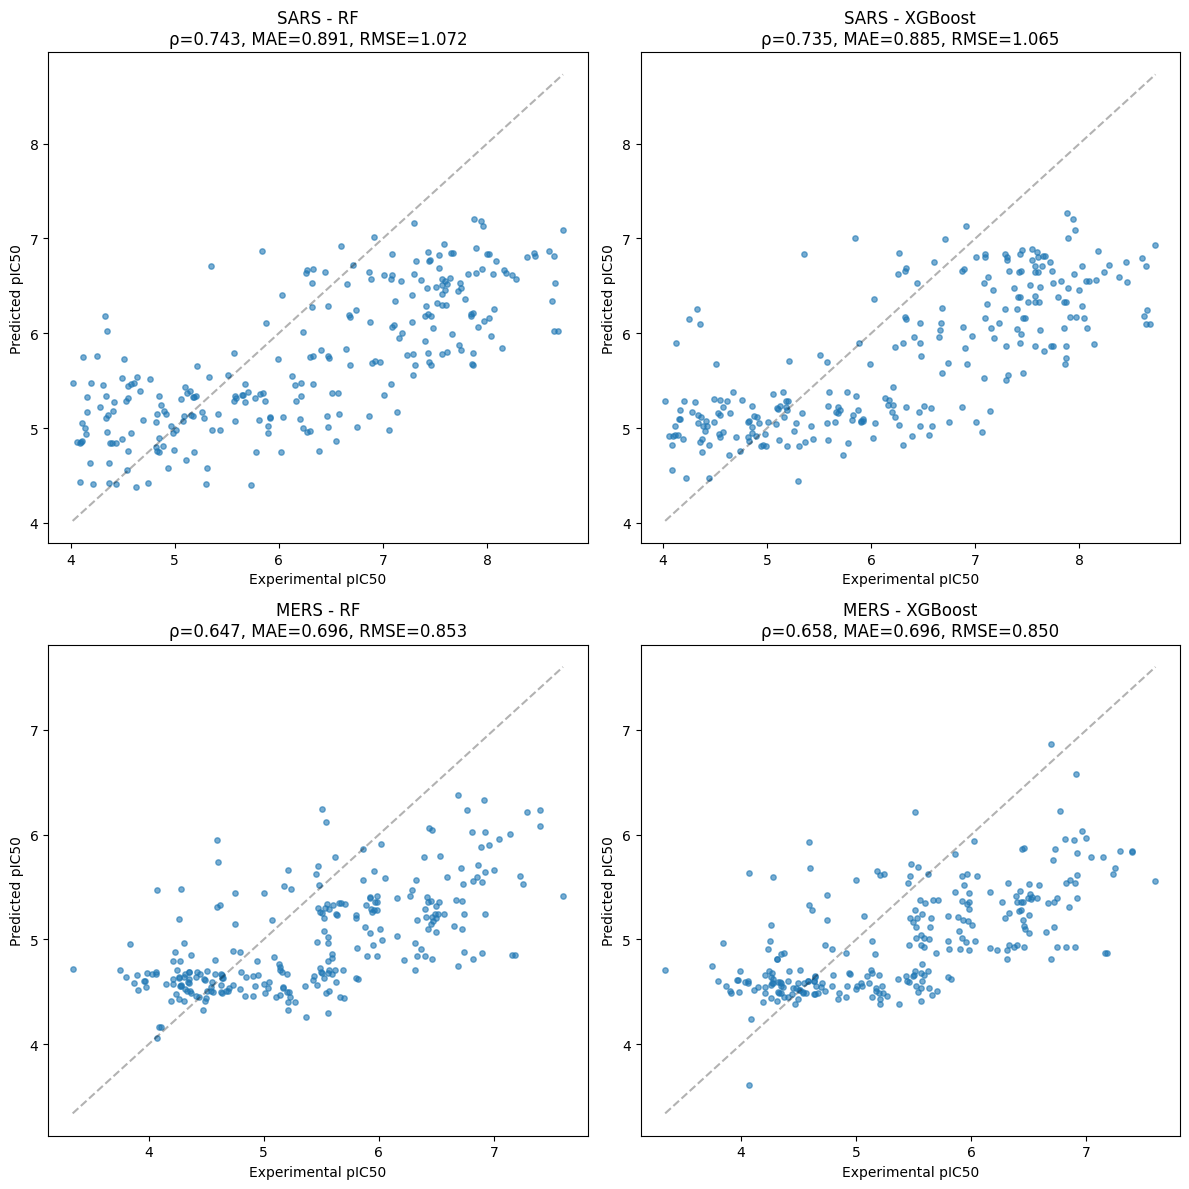

In [12]:
# --- Cell 13: Scatter Plots for Tuned Models ---
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

for idx, (name, model) in enumerate(results.items()):
    ax = axes[idx // 2][idx % 2]
    target_test = test_y_sars if "SARS" in name else test_y_mers
    test_pred = model.predict(test_X)

    # Get metrics for title
    rho, _ = spearmanr(target_test, test_pred)
    mae = mean_absolute_error(target_test, test_pred)
    rmse = np.sqrt(mean_squared_error(target_test, test_pred))

    ax.scatter(target_test, test_pred, s=15, alpha=0.6)
    min_val = min(target_test.min(), test_pred.min())
    max_val = max(target_test.max(), test_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "k--", alpha=0.3)
    ax.set_xlabel("Experimental pIC50")
    ax.set_ylabel("Predicted pIC50")
    ax.set_title(f"{name}\nρ={rho:.3f}, MAE={mae:.3f}, RMSE={rmse:.3f}")

plt.tight_layout()
plt.show()

In [13]:
# --- Cell 14: Load and Predict on Unseen Data (Lightweight Only) ---

# Step 1: Load unseen molecules from .oez file
print("Loading unseen molecules...")
unseen_ifs = oechem.oemolistream("Cresset_OE_Mpro_76cmpds.oez")
unseen_mols = []
unseen_names = []

for mol in unseen_ifs.GetOEMols():
    unseen_mols.append(oechem.OEMol(mol))
    unseen_names.append(mol.GetTitle())

unseen_ifs.close()
print(f"Loaded {len(unseen_mols)} unseen molecules")

# Step 2: Compute lightweight features for unseen molecules
print("\nCalculating lightweight features for unseen molecules...")
area_calc = oezap.OEArea()
unseen_lightweight = []

for mol in unseen_mols:
    num_atoms = mol.NumAtoms()
    num_bonds = mol.NumBonds()
    volume = oeshape.OECalcVolume(mol)
    surface_area = area_calc.GetArea(mol)

    pmi = oechem.OEDoubleArray(3)
    oechem.OECalcPMI(pmi, mol)
    pmi_vals = [pmi[0], pmi[1], pmi[2]]
    max_pmi = max(pmi_vals) if max(pmi_vals) > 0 else 1.0
    npr1 = pmi_vals[0] / max_pmi
    npr2 = pmi_vals[1] / max_pmi

    unseen_lightweight.append([num_atoms, num_bonds, volume, surface_area, npr1, npr2])

unseen_features = np.array(unseen_lightweight)
print(f"Unseen feature matrix shape: {unseen_features.shape}")

# Step 3: Predict using tuned models
print("\n" + "=" * 60)
print("  PREDICTIONS ON UNSEEN DATA (Lightweight Only)")
print("=" * 60)

for name, model in results.items():
    preds = model.predict(unseen_features)
    print(f"\n{name}:")
    print(f"  Predicted pIC50 range: {preds.min():.3f} to {preds.max():.3f}")
    print(f"  Predicted pIC50 mean:  {preds.mean():.3f}")

# Step 4: Save predictions
pred_df = pd.DataFrame({"Molecule Name": unseen_names})
for name, model in results.items():
    col_name = name.replace(" - ", "_").replace(" ", "_")
    pred_df[col_name] = model.predict(unseen_features)

pred_df.to_csv("unseen_predictions_lightweight.csv", index=False)
print("\nSaved to unseen_predictions_lightweight.csv")

Loading unseen molecules...
Loaded 76 unseen molecules

Calculating lightweight features for unseen molecules...
Unseen feature matrix shape: (76, 6)

  PREDICTIONS ON UNSEEN DATA (Lightweight Only)

SARS - RF:
  Predicted pIC50 range: 4.369 to 6.813
  Predicted pIC50 mean:  5.544

SARS - XGBoost:
  Predicted pIC50 range: 4.375 to 6.234
  Predicted pIC50 mean:  5.368

MERS - RF:
  Predicted pIC50 range: 4.138 to 6.061
  Predicted pIC50 mean:  4.872

MERS - XGBoost:
  Predicted pIC50 range: 3.615 to 5.929
  Predicted pIC50 mean:  4.659

Saved to unseen_predictions_lightweight.csv
